<a href="https://colab.research.google.com/github/suvarnaj3/early_sepsis_prediction/blob/main/SMOTE_%2B_Class_Weights_sepsis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost lightgbm imbalanced-learn

In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Load Data
import os
import pandas as pd

# ✅ Create folder if it doesn't exist
folder_path = "/content/drive/MyDrive/sepsis_project"
os.makedirs(folder_path, exist_ok=True)

save_path = os.path.join(folder_path, "hourly_data.pkl")

# If file exists → load
if os.path.exists(save_path):
    print("Loading from saved file...")
    data = pd.read_pickle(save_path)

else:
    print("Reading raw files (first time only)...")

    data_path = "/content/drive/MyDrive/training_setA/training_setA"
    files = sorted(os.listdir(data_path))

    important_cols = [
        'HR','O2Sat','Temp','SBP','MAP','DBP','Resp',
        'Creatinine','BUN','WBC','Platelets','Lactate',
        'Age','Gender','ICULOS','SepsisLabel'
    ]

    dfs = []

    for file in files[:5000]:
        temp_df = pd.read_csv(
            os.path.join(data_path, file),
            sep='|',
            usecols=important_cols
        )

        temp_df["PatientID"] = file
        dfs.append(temp_df)

    data = pd.concat(dfs, ignore_index=True)

    # ✅ Save now works
    data.to_pickle(save_path)
    print("Saved for future fast loading!")

Reading raw files (first time only)...
Saved for future fast loading!


In [ ]:
#Create Early Sepsis Label (6 hours before)
data["SepsisLabel_Early"] = (
    data.groupby("PatientID")["SepsisLabel"]
    .shift(-6)
)

data["SepsisLabel_Early"] = data["SepsisLabel_Early"].fillna(0)

In [ ]:
#Feature Engineering (Time-Based)
for col in ['HR','Temp','MAP','Resp','Lactate','WBC']:

    # Rolling mean (6 hours)
    data[f"{col}_mean_6h"] = (
        data.groupby("PatientID")[col]
        .rolling(6)
        .mean()
        .reset_index(level=0, drop=True)
    )

    # Hourly change
    data[f"{col}_delta_1h"] = (
        data.groupby("PatientID")[col]
        .diff()
    )

In [ ]:
#Convert Hourly → Patient-Level
# Drop original label
features = [col for col in data.columns
            if col not in ["SepsisLabel", "SepsisLabel_Early", "PatientID"]]

# Aggregate features
agg_dict = {}
for col in features:
    agg_dict[col] = ['mean', 'max', 'min', 'last']

patient_data = data.groupby("PatientID").agg(agg_dict)

# Flatten column names
patient_data.columns = [
    f"{col}_{stat}" for col, stat in patient_data.columns
]

# Target: did patient develop sepsis early?
patient_labels = data.groupby("PatientID")["SepsisLabel_Early"].max()

final_data = patient_data.copy()
final_data["Target"] = patient_labels
final_data = final_data.reset_index()


In [ ]:
save_path_pkl = "/content/drive/MyDrive/sepsis_project/patient_level_data.pkl"

final_data.to_pickle(save_path_pkl)

print("Saved patient-level data (pickle) at:", save_path_pkl)

Saved patient-level data (pickle) at: /content/drive/MyDrive/sepsis_project/patient_level_data.pkl


In [ ]:
save_path_csv = "/content/drive/MyDrive/sepsis_project/patient_level_data.csv"

final_data.to_csv(save_path_csv, index=False)

print("Saved patient-level data (csv) at:", save_path_csv)

Saved patient-level data (csv) at: /content/drive/MyDrive/sepsis_project/patient_level_data.csv


In [ ]:
print(os.path.exists(save_path_pkl))
print(os.path.exists(save_path_csv))

True
True


In [ ]:
#load data again....
import pandas as pd

final_data = pd.read_pickle("/content/drive/MyDrive/sepsis_project/patient_level_data.pkl")

X = final_data.drop(columns=["PatientID", "Target"])
y = final_data["Target"]

In [ ]:
from sklearn.model_selection import train_test_split

X = final_data.drop(columns=["PatientID", "Target"])
y = final_data["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_smote))

# Class weights
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
print("Class Weights:", class_weights)

Before SMOTE: [3643  357]
After SMOTE: [3643 3643]
Class Weights: {np.float64(0.0): np.float64(0.5489980785067252), np.float64(1.0): np.float64(5.602240896358543)}


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight=class_weights)
lr.fit(X_train_smote, y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight={np.float64(0.0): np.float64(0.5489980785067252),
                                 np.float64(1.0): np.float64(5.602240896358543)},
                   max_iter=1000)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight={np.float64(0.0): np.float64(0.5489980785067252),
                                     np.float64(1.0): np.float64(5.602240896358543)},
                       random_state=42)

In [ ]:
from xgboost import XGBClassifier

scale_pos_weight = class_weights[1] / class_weights[0]

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42
)

lgbm.fit(X_train_smote, y_train_smote)

[LightGBM] [Info] Number of positive: 3643, number of negative: 3643
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016953 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25128
[LightGBM] [Info] Number of data points in the train set: 7286, number of used features: 108
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.910750 -> initscore=2.322827
[LightGBM] [Info] Start training from score 2.322827


LGBMClassifier(class_weight={np.float64(0.0): np.float64(0.5489980785067252),
                             np.float64(1.0): np.float64(5.602240896358543)},
               random_state=42)

In [ ]:
#Evaluate Models
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    print("AUROC:", roc_auc_score(y_test, y_prob))
    print("PR-AUC:", average_precision_score(y_test, y_prob))


===== Logistic Regression =====
              precision    recall  f1-score   support

         0.0       0.97      0.23      0.37       911
         1.0       0.11      0.93      0.19        89

    accuracy                           0.29      1000
   macro avg       0.54      0.58      0.28      1000
weighted avg       0.89      0.29      0.35      1000

AUROC: 0.7393159757767116
PR-AUC: 0.25041990255860447

===== Random Forest =====
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97       911
         1.0       0.74      0.47      0.58        89

    accuracy                           0.94      1000
   macro avg       0.84      0.73      0.77      1000
weighted avg       0.93      0.94      0.93      1000

AUROC: 0.8417037703967736
PR-AUC: 0.597929765575143

===== XGBoost =====
              precision    recall  f1-score   support

         0.0       0.97      0.92      0.94       911
         1.0       0.47      0.69      0.55       

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
def plot_cm(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

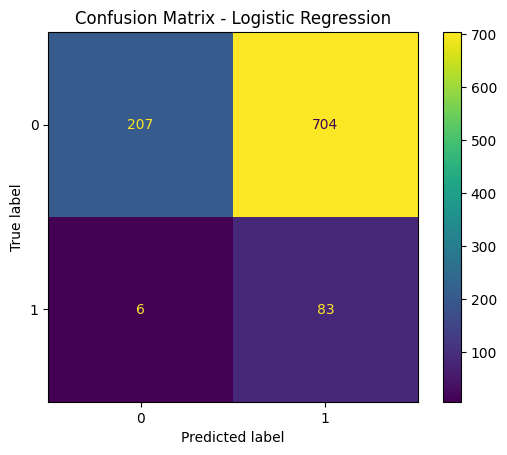

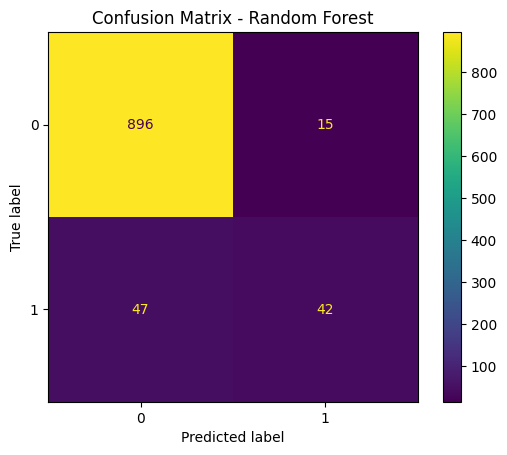

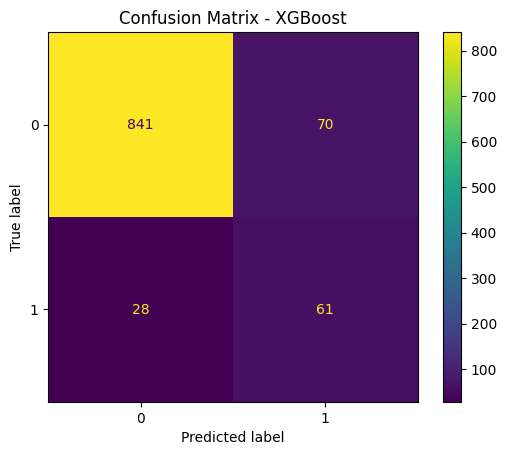

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


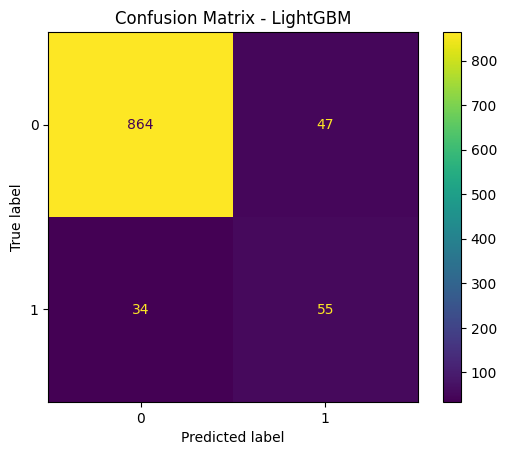

In [ ]:
plot_cm(lr, X_test, y_test, "Logistic Regression")
plot_cm(rf, X_test, y_test, "Random Forest")
plot_cm(xgb, X_test, y_test, "XGBoost")
plot_cm(lgbm, X_test, y_test, "LightGBM")

In [ ]:
def plot_cm_pretty(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f"{model_name}")
    plt.colorbar()

    classes = ["No Sepsis", "Sepsis"]
    tick_marks = range(len(classes))

    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    for i in range(len(classes)):
        for j in range(len(classes)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

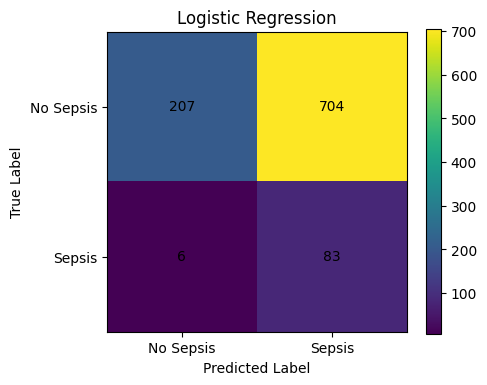

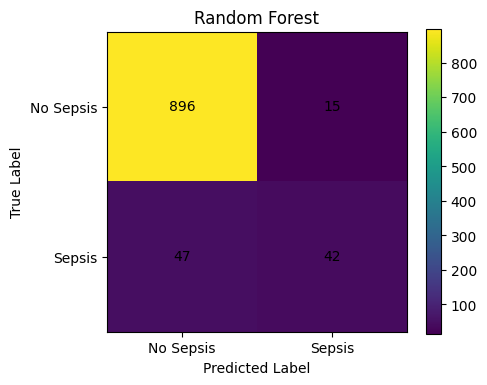

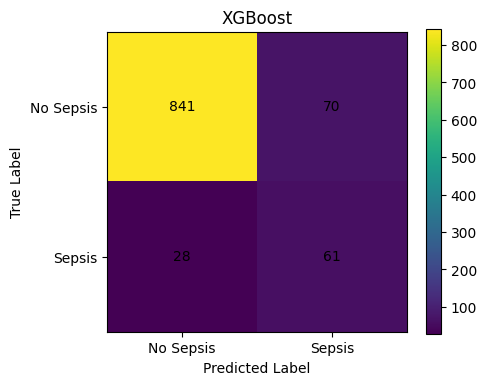

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


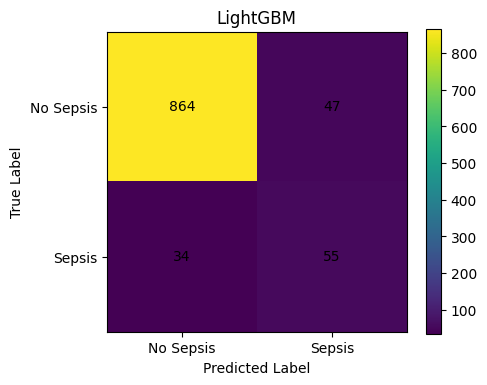

In [ ]:
plot_cm_pretty(lr, X_test, y_test, "Logistic Regression")
plot_cm_pretty(rf, X_test, y_test, "Random Forest")
plot_cm_pretty(xgb, X_test, y_test, "XGBoost")
plot_cm_pretty(lgbm, X_test, y_test, "LightGBM")

In [ ]:
def save_cm(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(model_name)
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig(f"/content/drive/MyDrive/sepsis_project/{model_name}_cm.png")
    plt.close()

In [ ]:
save_cm(lr, X_test, y_test, "Logistic_Regression")
save_cm(rf, X_test, y_test, "Random_Forest")
save_cm(xgb, X_test, y_test, "XGBoost")
save_cm(lgbm, X_test, y_test, "LightGBM")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print(f"\n{name}")
    print("False Negatives:", fn)


Logistic Regression
False Negatives: 6

Random Forest
False Negatives: 47

XGBoost
False Negatives: 28

LightGBM
False Negatives: 34


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print(f"\n{name}")
    print("True Positives (TP):", tp)


Logistic Regression
True Positives (TP): 83

Random Forest
True Positives (TP): 42

XGBoost
True Positives (TP): 61

LightGBM
True Positives (TP): 55


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
!pip install joblib

In [ ]:
import os

model_path = "/content/drive/MyDrive/sepsis_project/models"
os.makedirs(model_path, exist_ok=True)

In [ ]:
import joblib

joblib.dump(lr, f"{model_path}/logistic_regression.pkl")
joblib.dump(rf, f"{model_path}/random_forest.pkl")
joblib.dump(xgb, f"{model_path}/xgboost.pkl")
joblib.dump(lgbm, f"{model_path}/lightgbm.pkl")

print("All models saved successfully!")

All models saved successfully!


In [ ]:
import joblib

lr = joblib.load(f"{model_path}/logistic_regression.pkl")
rf = joblib.load(f"{model_path}/random_forest.pkl")
xgb = joblib.load(f"{model_path}/xgboost.pkl")
lgbm = joblib.load(f"{model_path}/lightgbm.pkl")

print("Models loaded successfully!")

Models loaded successfully!


In [ ]:
final_data.to_pickle("/content/drive/MyDrive/sepsis_project/final_data.pkl")

In [ ]:
joblib.dump(X.columns.tolist(), f"{model_path}/features.pkl")

['/content/drive/MyDrive/sepsis_project/models/features.pkl']